# 🛒 Retail Sales Management & Data Analysis

### 🎯 Project Goals
- 🧾 Manage retail sales records
- 💰 Calculate total sales and revenue
- 📊 Generate useful retail sales reports
- 📈 Analyze sales using charts
- 🔎 Understand category and product performance
- 📅 Study sales trends over time


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date


## 📂 1. Load the Dataset

The project uses the `retail_sales.csv` file.

The dataset contains:
- `Sale_ID` → unique sale number
- `Date` → date of the sale
- `Category` → product category
- `Product` → product name
- `Quantity` → number of units sold
- `Unit_Price` → price of one unit
- `Total_Sales` → total amount of the sale


In [2]:
sales = pd.read_csv("retail_sales.csv")
sales["Date"] = pd.to_datetime(sales["Date"])


## 📋 2. View Retail Sales Data

Let's display the dataset to understand its structure and the information available before performing analysis.


In [3]:
print("Retail Sales Data")
print(sales)


Retail Sales Data
    Sale_ID       Date     Category     Product  Quantity  Unit_Price  \
0         1 2026-01-05  Electronics      Laptop         2       55000   
1         2 2026-01-06  Electronics  Smartphone         3       25000   
2         3 2026-01-08     Clothing     T-Shirt        10         500   
3         4 2026-01-10     Clothing       Jeans         5        1200   
4         5 2026-01-12      Grocery        Rice        20          80   
5         6 2026-01-15      Grocery         Oil        15         150   
6         7 2026-01-18  Electronics      Laptop         1       55000   
7         8 2026-01-20  Electronics  Headphones         8        1500   
8         9 2026-01-22     Clothing     T-Shirt        12         500   
9        10 2026-01-25      Grocery        Rice        25          80   
10       11 2026-01-27  Electronics  Smartphone         2       25000   
11       12 2026-01-30     Clothing       Jeans         7        1200   

    Total_Sales  
0        11000

## 🏪 3. Retail Sales Management System

The `RetailStore` class provides a simple menu-driven system for managing sales records.

### ✨ Main Features
1. ➕ **Add Sale**
2. 🔄 **Update Sale**
3. ❌ **Delete Sale**
4. 📊 **Generate Report**
5. 👀 **View Sales**


In [4]:
class RetailStore:
    def __init__(self, sales):
        self.sales = sales

    # ---------------- ADD SALE ----------------
    def add_sale(self):
        sale_id = int(input("Enter Sale ID: "))
        date_value = input("Enter Date (YYYY-MM-DD): ")
        category = input("Enter Category: ")
        product = input("Enter Product: ")
        quantity = int(input("Enter Quantity: "))
        unit_price = float(input("Enter Unit Price: "))

        total_sales = quantity * unit_price

        new_sale = pd.DataFrame({
            "Sale_ID": [sale_id],
            "Date": [date_value],
            "Category": [category],
            "Product": [product],
            "Quantity": [quantity],
            "Unit_Price": [unit_price],
            "Total_Sales": [total_sales]
        })

        self.sales = pd.concat([self.sales, new_sale], ignore_index=True)
        self.sales.to_csv("retail_sales.csv", index=False)

        print("Sale added successfully.")

    # ---------------- UPDATE SALE ----------------
    def update_sale(self):
        sale_id = int(input("Enter Sale ID to update: "))

        if sale_id in self.sales["Sale_ID"].values:
            quantity = int(input("Enter new Quantity: "))
            unit_price = float(input("Enter new Unit Price: "))

            index = self.sales[self.sales["Sale_ID"] == sale_id].index[0]

            self.sales.loc[index, "Quantity"] = quantity
            self.sales.loc[index, "Unit_Price"] = unit_price
            self.sales.loc[index, "Total_Sales"] = quantity * unit_price

            self.sales.to_csv("retail_sales.csv", index=False)
            print("Sale updated successfully.")
        else:
            print("Sale ID not found.")

    # ---------------- DELETE SALE ----------------
    def delete_sale(self):
        sale_id = int(input("Enter Sale ID to delete: "))

        if sale_id in self.sales["Sale_ID"].values:
            self.sales = self.sales[self.sales["Sale_ID"] != sale_id]
            self.sales.to_csv("retail_sales.csv", index=False)
            print("Sale deleted successfully.")
        else:
            print("Sale ID not found.")

    # ---------------- REPORT ----------------
    def report(self):
        print("\n----- RETAIL SALES REPORT -----")
        print("Total Transactions:", len(self.sales))
        print("Total Quantity Sold:", self.sales["Quantity"].sum())
        print("Total Revenue: ₹", self.sales["Total_Sales"].sum())

    # ---------------- VIEW SALES ----------------
    def view_sales(self):
        print(self.sales)


# Create object
store = RetailStore(sales)

# Run this when you want to use the management system:
# store.view_sales()
# store.report()


## 🔄 4. Reload Updated Data

After using the retail management system, the CSV file can be loaded again so the latest sales information can be analyzed.


In [5]:
sales = pd.read_csv("retail_sales.csv")
sales["Date"] = pd.to_datetime(sales["Date"])


## 👀 5. Preview Retail Sales Data

`head()` displays the first five rows of the dataset. This gives a quick overview of the sales records.


In [6]:
sales.head()


,Sale_ID,Date,Category,Product,Quantity,Unit_Price,Total_Sales
0,1,2026-01-05,Electronics,Laptop,2,55000,110000
1,2,2026-01-06,Electronics,Smartphone,3,25000,75000
2,3,2026-01-08,Clothing,T-Shirt,10,500,5000
3,4,2026-01-10,Clothing,Jeans,5,1200,6000
4,5,2026-01-12,Grocery,Rice,20,80,1600


## 📊 6. Retail Sales Statistical Summary

`describe()` provides basic statistical information for the numerical columns, including:

- 🔢 Count
- 📌 Mean
- 📉 Standard deviation
- ⬇️ Minimum value
- 📍 Quartiles
- ⬆️ Maximum value


In [7]:
sales.describe()


,Sale_ID,Date,Quantity,Unit_Price,Total_Sales
count,12.000000,12,12.000000,12.000000,12.000000
mean,6.500000,2026-01-16 12:00:00,9.166667,13767.500000,27770.833333
min,1.000000,2026-01-05 00:00:00,1.000000,80.000000,1600.000000
25%,3.750000,2026-01-09 12:00:00,2.750000,412.500000,4312.500000
50%,6.500000,2026-01-16 12:00:00,7.500000,1200.000000,7200.000000
75%,9.250000,2026-01-22 18:00:00,12.750000,25000.000000,51250.000000
max,12.000000,2026-01-30 00:00:00,25.000000,55000.000000,110000.000000
std,3.605551,NaN,7.637626,21386.352116,36078.893719


## 📈 7. Total Sales by Product

This bar chart compares the total revenue generated by each product. It helps identify which products contribute the most to sales.


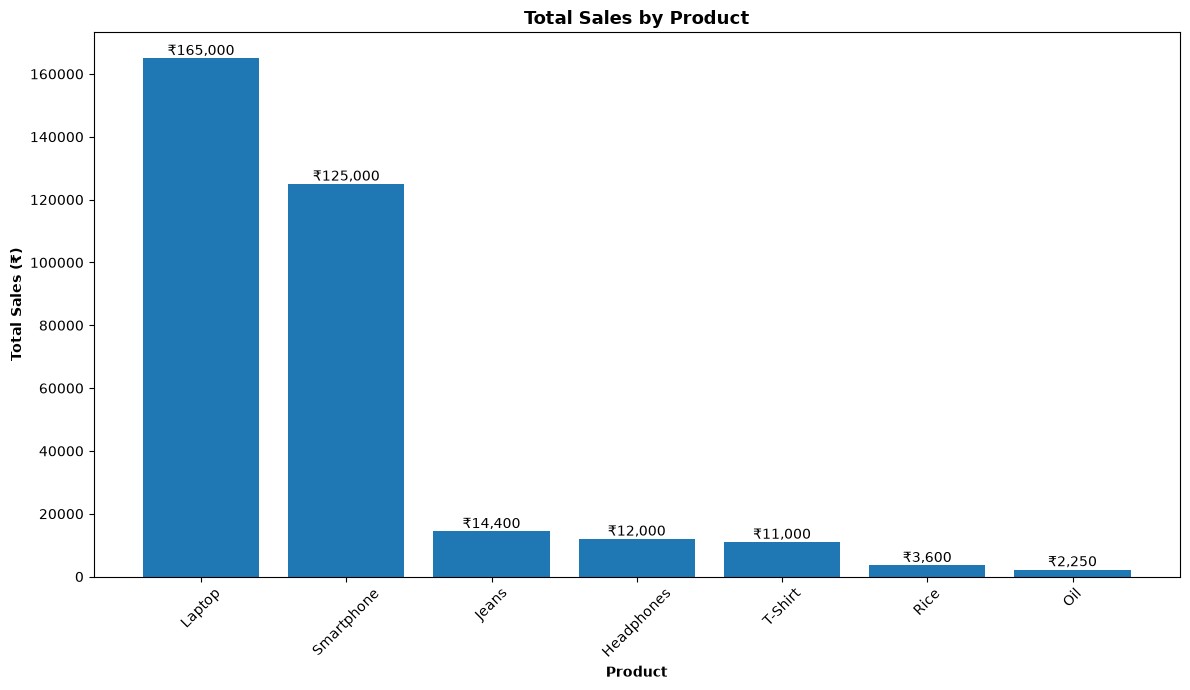

In [8]:
product_sales = sales.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
bars = plt.bar(product_sales.index, product_sales.values)

for bar, value in zip(bars, product_sales.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Product", fontweight="bold")
plt.ylabel("Total Sales (₹)", fontweight="bold")
plt.title("Total Sales by Product", fontweight="bold", fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 🥧 8. Sales by Category

This pie chart shows how total sales are distributed across product categories. It helps us understand which category generates more revenue.


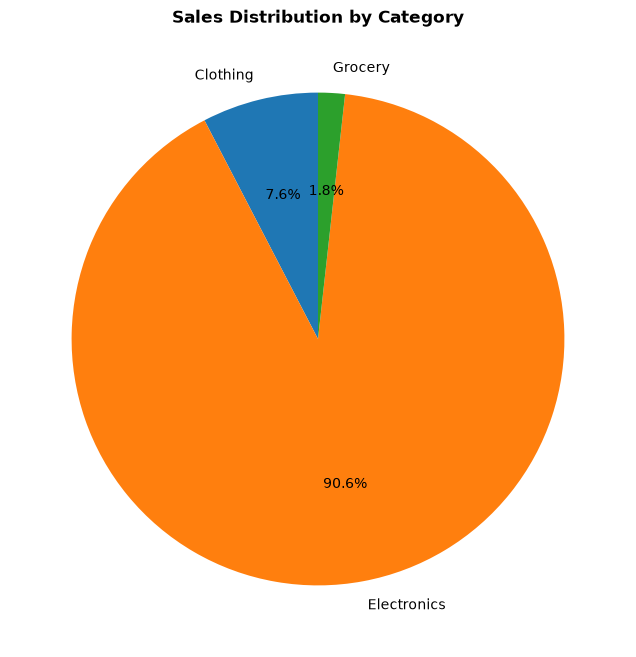

In [9]:
category_sales = sales.groupby("Category")["Total_Sales"].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10}
)
plt.title("Sales Distribution by Category", fontweight="bold")
plt.show()


## 🔵 9. Unit Price vs Quantity Analysis

The scatter plot compares the unit price of products with the quantity sold.

This visualization helps us see whether higher-priced products tend to have lower or higher sales quantities.


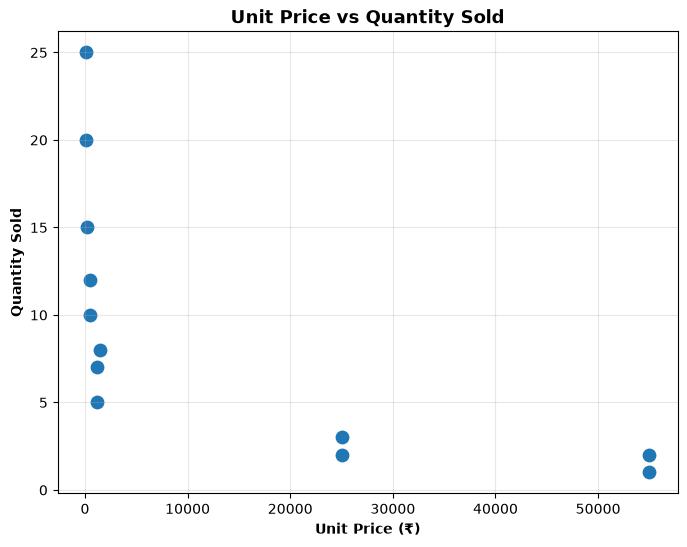

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(sales["Unit_Price"], sales["Quantity"], s=80)

plt.xlabel("Unit Price (₹)", fontweight="bold")
plt.ylabel("Quantity Sold", fontweight="bold")
plt.title("Unit Price vs Quantity Sold", fontweight="bold", fontsize=13)
plt.grid(alpha=0.3)
plt.show()


## 🔗 10. Correlation Between Unit Price and Quantity

The correlation matrix measures the relationship between unit price and quantity sold.

- A value close to **+1** indicates a strong positive relationship.
- A value close to **-1** indicates a strong negative relationship.
- A value close to **0** indicates a weak relationship.


In [11]:
data = sales[["Unit_Price", "Quantity"]]

corr = data.corr()
corr


,Unit_Price,Quantity
Unit_Price,1.000000,-0.657395
Quantity,-0.657395,1.000000


## 🔥 11. Unit Price & Quantity Correlation Heatmap

The heatmap presents the correlation values visually. The `annot=True` option displays the exact correlation values inside the cells.


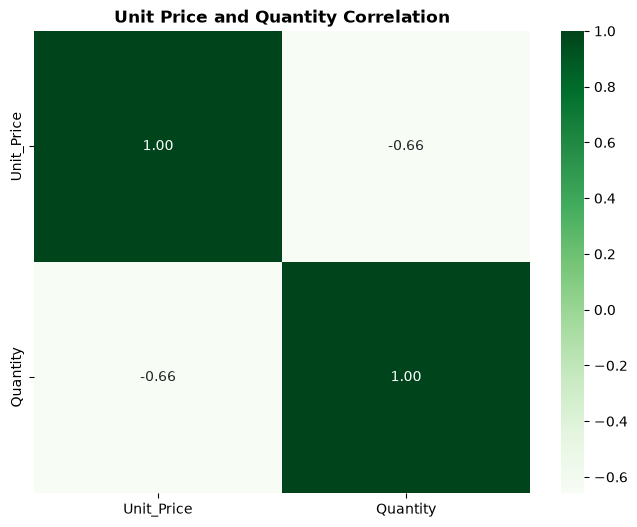

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Greens", fmt=".2f")
plt.title("Unit Price and Quantity Correlation", fontweight="bold")
plt.show()


## 🧾 12. Preview Sales Data

Let's display the first five sales transactions again before analyzing revenue and quantity sold.


In [13]:
sales.head()


,Sale_ID,Date,Category,Product,Quantity,Unit_Price,Total_Sales
0,1,2026-01-05,Electronics,Laptop,2,55000,110000
1,2,2026-01-06,Electronics,Smartphone,3,25000,75000
2,3,2026-01-08,Clothing,T-Shirt,10,500,5000
3,4,2026-01-10,Clothing,Jeans,5,1200,6000
4,5,2026-01-12,Grocery,Rice,20,80,1600


## 💰 13. Sales Statistical Summary

This summary provides statistics for quantity sold, unit price, and total sales. It helps us understand the typical transaction size and revenue.


In [14]:
sales[["Quantity", "Unit_Price", "Total_Sales"]].describe()


,Quantity,Unit_Price,Total_Sales
count,12.000000,12.000000,12.000000
mean,9.166667,13767.500000,27770.833333
std,7.637626,21386.352116,36078.893719
min,1.000000,80.000000,1600.000000
25%,2.750000,412.500000,4312.500000
50%,7.500000,1200.000000,7200.000000
75%,12.750000,25000.000000,51250.000000
max,25.000000,55000.000000,110000.000000


## 📦 14. Quantity Sold by Product

This bar chart compares the total number of units sold for each product. It helps identify products with higher sales activity.


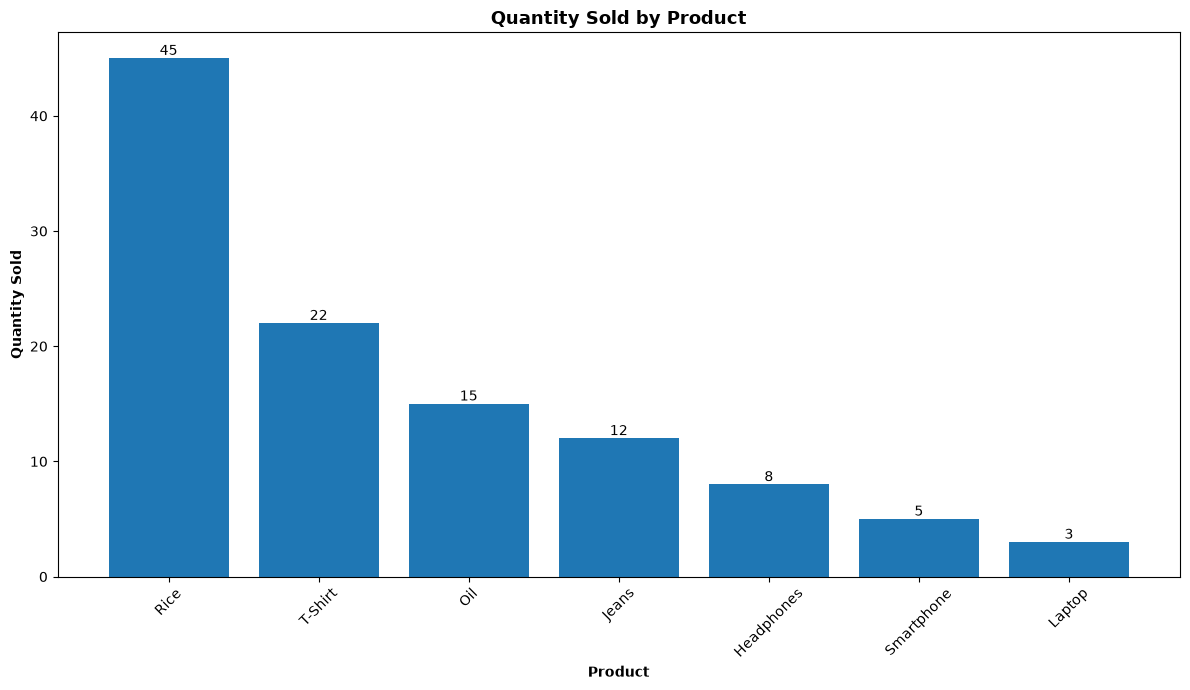

In [15]:
product_quantity = sales.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
bars = plt.bar(product_quantity.index, product_quantity.values)

for bar, value in zip(bars, product_quantity.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom"
    )

plt.xlabel("Product", fontweight="bold")
plt.ylabel("Quantity Sold", fontweight="bold")
plt.title("Quantity Sold by Product", fontweight="bold", fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 📅 15. Sales Trend Over Time

The line chart shows total sales over the recorded dates. It can help identify increases or decreases in revenue over time.


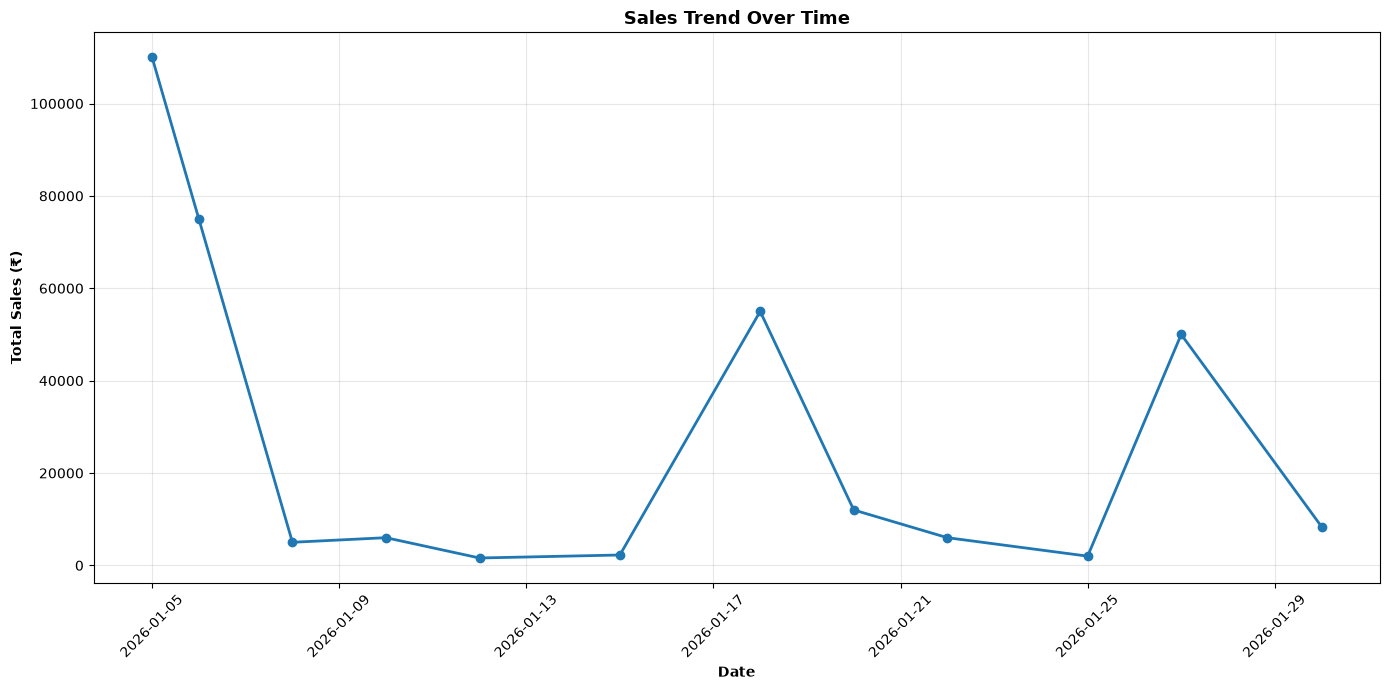

In [16]:
daily_sales = sales.groupby("Date")["Total_Sales"].sum()

plt.figure(figsize=(14, 7))
plt.plot(daily_sales.index, daily_sales.values, marker="o", linewidth=2)

plt.xlabel("Date", fontweight="bold")
plt.ylabel("Total Sales (₹)", fontweight="bold")
plt.title("Sales Trend Over Time", fontweight="bold", fontsize=13)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 💹 16. Quantity Sold & Total Sales Correlation

This final heatmap shows the relationship between **Quantity Sold** and **Total Sales**.

Because total sales are calculated from quantity and unit price, this helps us understand the relationship between the number of units sold and revenue.


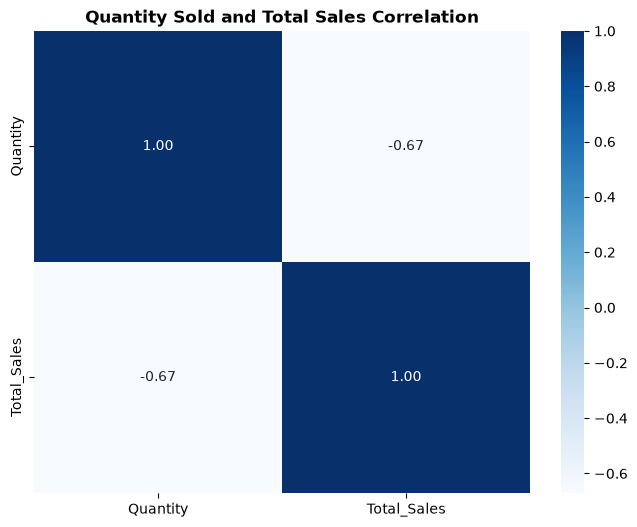

In [17]:
data = sales[["Quantity", "Total_Sales"]]
corr = data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Quantity Sold and Total Sales Correlation", fontweight="bold")
plt.show()


# 🗝️ Key Takeaways

### 🛒 Retail Sales
- The dataset contains retail transactions across multiple product categories.
- `Total_Sales` represents the revenue generated from each transaction.
- Product-wise analysis helps identify the products generating higher revenue.
- Category-wise analysis shows which categories contribute more to total sales.
- Quantity analysis identifies products with higher sales volume.
- The sales trend chart shows how revenue changes over the recorded dates.
- Correlation analysis helps understand relationships between price, quantity, and sales.
